# Selection of the fixed spatial test set

This notebook freezes the spatial test set used for EPVI prediction. The test set remains a union of whole NUTS3 regions so that the final evaluation measures transfer to held-out regions rather than a random-row split.

The previous fixed test set was `PT16E` + `PT16J`. It was useful for exposing a weakness in the first spatial workflow, but it held out only about 14% of the corrected modeling rows and the observed `EPG cooling` values were strongly shifted toward the ceiling value 20. A fixed evaluation set with that shift would make it hard to distinguish model weakness from an atypical target distribution.

The rule below therefore ranks unions of whole NUTS3 regions that contain 18% to 22% of the corrected modeling table. The primary objective is similarity between test-set and Portugal-wide `EPG heating` and `EPG cooling` distributions. The score sums total-variation distances for both EPG empirical distributions, absolute differences in the `EPG cooling == 20` and `EPG cooling >= 19` shares, a small penalty for AIAM/EPVI mean shifts, and a small penalty for deviation from exactly 20% of rows. Candidate size is constrained before scoring.

Two whole NUTS3 regions cannot reach the size constraint in the corrected table. The selected candidate is the lowest-scoring eligible candidate among two-, three-, and four-region unions and is then frozen in `pipeline/3_epvi_prediction/utils.py`.

In [1]:
from __future__ import annotations

from itertools import combinations
from importlib import import_module, reload
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
try:
    from IPython.display import display
except Exception:
    display = print

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pipeline" / "config").exists())
sys.path.append(str(REPO_ROOT))

from pipeline.utils.paths import load_paths, path_value, repo_data_path

rf_utils = reload(import_module("pipeline.3_epvi_prediction.utils"))
PATHS = load_paths()
SAT_CSV, REGENERATED_SAT_CSV, SNAPSHOT_SAT_CSV = rf_utils.choose_satellite_csv(PATHS, repo_data_path, path_value)
ADM_CSV = repo_data_path(PATHS, "all_used_adm_indicators.csv")
ADM_SPLIT_JSON = repo_data_path(PATHS, "adm_data_split.json")
NUTS3_MAPPING_CSV = repo_data_path(PATHS, "freguesias_to_NUTS3.csv")
PARISH_GEOMETRY_GEOJSON = repo_data_path(PATHS, "parishes.geojson")
EPVI_CSV = path_value(PATHS, "epvi_csv")

print("path config:", PATHS["_config_path"])
print("satellite predictors:", SAT_CSV)
print("private EPVI targets:", EPVI_CSV)

path config: E:\git_projects\energy_poverty_from_space\pipeline\config\paths.example.json
satellite predictors: E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\outputs\indices\freguesia_indices_streaming.csv
private EPVI targets: E:\OneDrive\Studia\Studia magisterskie\Masterarbeit 2 - Sozialwissenschaften\data\EPVI_results_gouveia_et_al_2019.csv


In [2]:
inputs = rf_utils.load_prediction_inputs(
    sat_csv=SAT_CSV,
    adm_csv=ADM_CSV,
    epvi_csv=EPVI_CSV,
    adm_split_json=ADM_SPLIT_JSON,
)
model_df, predictor_cols, constant_cols = rf_utils.build_modeling_table(inputs)
nuts3_mapping = rf_utils.load_nuts3_mapping(NUTS3_MAPPING_CSV)
model_df = rf_utils.attach_nuts3(model_df, nuts3_mapping)

region_sizes = model_df["NUTS3"].value_counts().sort_index().rename("n_rows").to_frame()
region_sizes["row_share"] = region_sizes["n_rows"] / len(model_df)
print("Corrected modeling rows:", len(model_df))
print("NUTS3 regions:", model_df["NUTS3"].nunique())
display(region_sizes.sort_values("n_rows", ascending=False))

Corrected modeling rows: 3092
NUTS3 regions: 25


,n_rows,row_share
NUTS3,,
PT16J,266,0.086028
PT11D,217,0.070181
PT111,208,0.067270
PT11E,195,0.063066
PT11C,177,0.057245
PT11A,173,0.055951
PT112,170,0.054981
PT119,168,0.054334
PT16E,168,0.054334


In [3]:
TARGET_SHARE = 0.20
MIN_SHARE = 0.18
MAX_SHARE = 0.22
CANDIDATE_REGION_COUNTS = (2, 3, 4)
PRIMARY_EPG_TARGETS = ["EPG heating", "EPG cooling"]
SECONDARY_TARGETS = ["AIAM", "EPVI heating", "EPVI cooling"]

def empirical_probabilities(values):
    return pd.Series(values).dropna().value_counts(normalize=True)

def total_variation(left, right):
    support = left.index.union(right.index)
    return 0.5 * float((left.reindex(support, fill_value=0) - right.reindex(support, fill_value=0)).abs().sum())

full_epg_distributions = {target: empirical_probabilities(model_df[target]) for target in PRIMARY_EPG_TARGETS}
secondary_means = model_df[SECONDARY_TARGETS].mean()
secondary_stds = model_df[SECONDARY_TARGETS].std(ddof=0).replace(0, np.nan)

def candidate_row(codes):
    test = model_df.loc[model_df["NUTS3"].isin(codes)]
    share = len(test) / len(model_df)
    epg_heating_tv = total_variation(empirical_probabilities(test["EPG heating"]), full_epg_distributions["EPG heating"])
    epg_cooling_tv = total_variation(empirical_probabilities(test["EPG cooling"]), full_epg_distributions["EPG cooling"])
    cooling_eq20_diff = abs(test["EPG cooling"].eq(20).mean() - model_df["EPG cooling"].eq(20).mean())
    cooling_ge19_diff = abs(test["EPG cooling"].ge(19).mean() - model_df["EPG cooling"].ge(19).mean())
    secondary_mean_z = (((test[SECONDARY_TARGETS].mean() - secondary_means).abs() / secondary_stds).mean())
    size_deviation_units = abs(share - TARGET_SHARE) / (MAX_SHARE - TARGET_SHARE)
    score = epg_heating_tv + epg_cooling_tv + cooling_eq20_diff + cooling_ge19_diff + 0.10 * secondary_mean_z + 0.05 * size_deviation_units
    return {
        "nuts3_codes": ", ".join(codes),
        "n_regions": len(codes),
        "n_rows": len(test),
        "row_share": share,
        "score": score,
        "epg_heating_tv": epg_heating_tv,
        "epg_cooling_tv": epg_cooling_tv,
        "epg_cooling_eq20_diff": cooling_eq20_diff,
        "epg_cooling_ge19_diff": cooling_ge19_diff,
        "secondary_mean_z": secondary_mean_z,
    }

codes = sorted(model_df["NUTS3"].unique())
candidates = pd.DataFrame(candidate_row(combo) for k in CANDIDATE_REGION_COUNTS for combo in combinations(codes, k))
eligible = candidates.loc[candidates["row_share"].between(MIN_SHARE, MAX_SHARE)].sort_values(["score", "nuts3_codes"]).reset_index(drop=True)
selected = eligible.iloc[0]

print("Candidate row-count ranges by region count:")
display(candidates.groupby("n_regions")["n_rows"].agg(["min", "max"]))
print("Eligible candidates by region count:")
display(eligible["n_regions"].value_counts().sort_index().rename("n_candidates").to_frame())
print("Top eligible candidates:")
display(eligible.head(20))
print("Frozen utility default:", rf_utils.DEFAULT_TEST_NUTS3)
print("Selected candidate:", selected["nuts3_codes"], f"({selected['n_rows']} rows, {selected['row_share']:.2%})")
assert tuple(selected["nuts3_codes"].split(", ")) == rf_utils.DEFAULT_TEST_NUTS3

Candidate row-count ranges by region count:


,min,max
n_regions,,
2,85,483
3,144,691
4,206,886


Eligible candidates by region count:


,n_candidates
n_regions,
3,89
4,3022


Top eligible candidates:


,nuts3_codes,n_regions,n_rows,row_share,score,epg_heating_tv,epg_cooling_tv,epg_cooling_eq20_diff,epg_cooling_ge19_diff,secondary_mean_z
0,"PT112, PT16B, PT16I, PT16J",4,618,0.199871,0.149584,0.059102,0.047525,0.014768,0.019856,0.080087
1,"PT112, PT16I, PT16J, PT170",4,647,0.209250,0.175703,0.081377,0.032295,0.000100,0.022223,0.165841
2,"PT112, PT16B, PT16J, PT170",4,643,0.207956,0.178761,0.072451,0.055970,0.001871,0.011403,0.171755
3,"PT112, PT16B, PT16J, PT187",4,594,0.192109,0.178777,0.052869,0.033011,0.028171,0.032883,0.121144
4,"PT112, PT16I, PT16J, PT185",4,597,0.193079,0.184880,0.054533,0.062000,0.026437,0.014237,0.103708
5,"PT119, PT16J, PT187, PT200",4,659,0.213131,0.190523,0.043159,0.069835,0.025997,0.006815,0.118897
6,"PT112, PT16J, PT200, PT300",4,646,0.208926,0.193481,0.074399,0.064127,0.000391,0.028327,0.039215
7,"PT112, PT16J, PT170, PT300",4,608,0.196636,0.196532,0.085680,0.057810,0.020224,0.009945,0.144639
8,"PT112, PT16J, PT170, PT186",4,623,0.201488,0.198471,0.078749,0.068691,0.012106,0.027100,0.081051
9,"PT112, PT150, PT16I, PT16J",4,596,0.192755,0.199572,0.057355,0.089035,0.027013,0.001380,0.066781


Frozen utility default: ('PT112', 'PT16B', 'PT16I', 'PT16J')
Selected candidate: PT112, PT16B, PT16I, PT16J (618 rows, 19.99%)


Previous fixed split diagnostics:


,nuts3_codes,n_regions,n_rows,row_share,score,epg_heating_tv,epg_cooling_tv,epg_cooling_eq20_diff,epg_cooling_ge19_diff,secondary_mean_z
213,"PT16E, PT16J",2,434,0.140362,1.354825,0.041078,0.459551,0.459551,0.225671,0.1988


Selected fixed split diagnostics:


,nuts3_codes,n_regions,n_rows,row_share,score,epg_heating_tv,epg_cooling_tv,epg_cooling_eq20_diff,epg_cooling_ge19_diff,secondary_mean_z
selected,"PT112, PT16B, PT16I, PT16J",4,618,0.199871,0.149584,0.059102,0.047525,0.014768,0.019856,0.080087


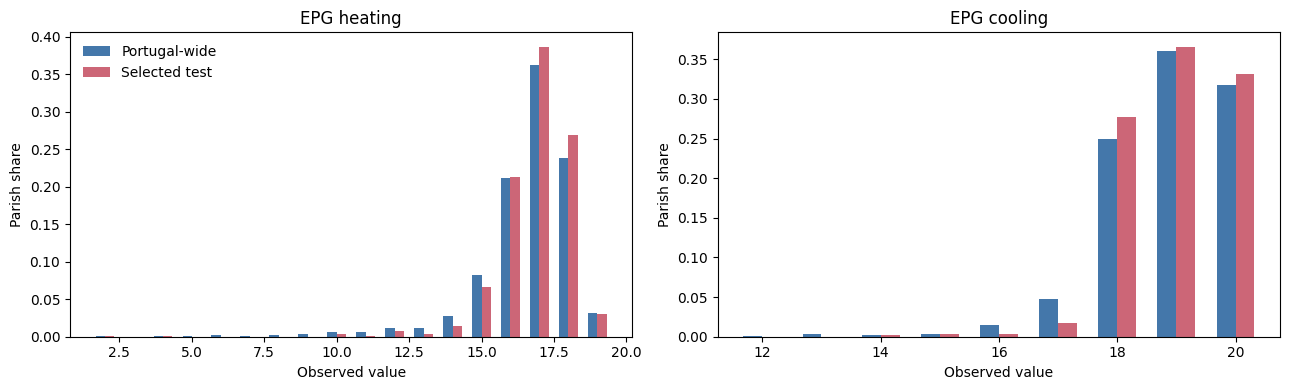

In [4]:
old_split = candidates.loc[candidates["nuts3_codes"].eq("PT16E, PT16J")]
selected_codes = tuple(selected["nuts3_codes"].split(", "))
selected_df = model_df.loc[model_df["NUTS3"].isin(selected_codes)].copy()

print("Previous fixed split diagnostics:")
display(old_split)
print("Selected fixed split diagnostics:")
display(selected.to_frame("selected").T)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, target in zip(axes, PRIMARY_EPG_TARGETS):
    values = sorted(model_df[target].dropna().unique())
    full = empirical_probabilities(model_df[target]).reindex(values, fill_value=0)
    test = empirical_probabilities(selected_df[target]).reindex(values, fill_value=0)
    ax.bar(np.array(values) - 0.16, full, width=0.32, label="Portugal-wide", color="#4477AA")
    ax.bar(np.array(values) + 0.16, test, width=0.32, label="Selected test", color="#CC6677")
    ax.set_title(target)
    ax.set_xlabel("Observed value")
    ax.set_ylabel("Parish share")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

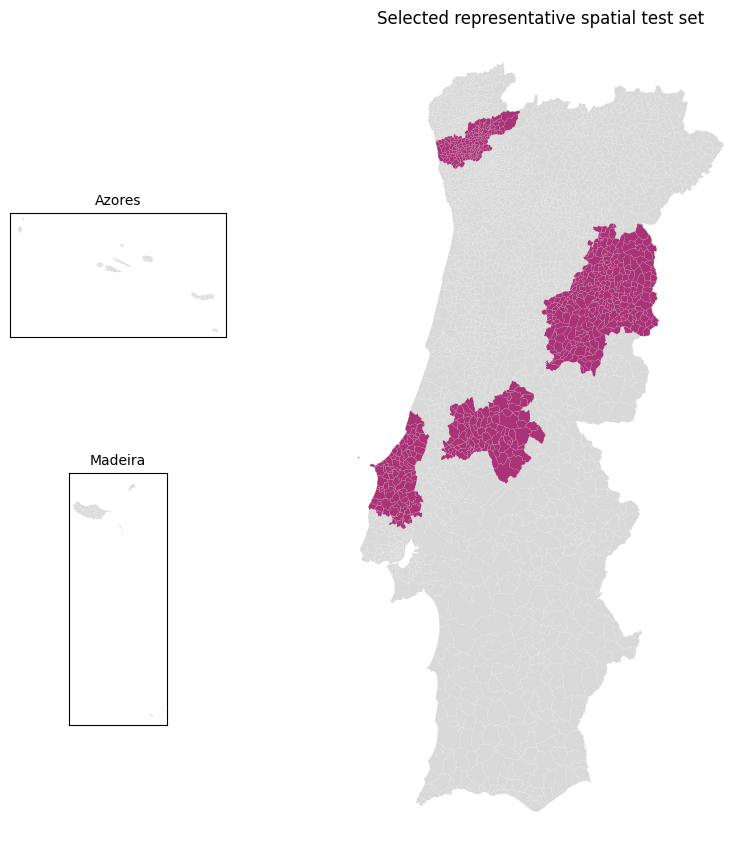

In [5]:
parishes = gpd.read_file(PARISH_GEOMETRY_GEOJSON)[["dicofre", "geometry"]].copy()
parishes["ID_norm"] = rf_utils.normalize_id(parishes["dicofre"])
test_ids = selected_df[["ID_norm", "NUTS3"]].drop_duplicates()
test_map = parishes.merge(nuts3_mapping, on="ID_norm", how="left")
test_map["in_selected_test"] = test_map["ID_norm"].isin(test_ids["ID_norm"])

def plot_selected_test(ax, gdf):
    gdf.plot(ax=ax, color="#D9D9D9", edgecolor="white", linewidth=0.03)
    selected_part = gdf.loc[gdf["in_selected_test"]]
    if not selected_part.empty:
        selected_part.plot(ax=ax, color="#AA3377", edgecolor="white", linewidth=0.04)
    minx, miny, maxx, maxy = gdf.total_bounds
    ax.set_xlim(minx - (maxx - minx) * 0.04, maxx + (maxx - minx) * 0.04)
    ax.set_ylim(miny - (maxy - miny) * 0.04, maxy + (maxy - miny) * 0.04)
    ax.set_xticks([])
    ax.set_yticks([])

mainland_map = test_map.loc[~test_map["NUTS3"].isin(["PT200", "PT300"])].copy()
azores_map = test_map.loc[test_map["NUTS3"].eq("PT200")].copy()
madeira_map = test_map.loc[test_map["NUTS3"].eq("PT300")].copy()

fig = plt.figure(figsize=(9, 9))
ax_main = fig.add_axes([0.32, 0.05, 0.64, 0.90])
ax_azores = fig.add_axes([0.05, 0.54, 0.24, 0.28], frameon=True)
ax_madeira = fig.add_axes([0.05, 0.18, 0.24, 0.28], frameon=True)
plot_selected_test(ax_main, mainland_map)
plot_selected_test(ax_azores, azores_map)
plot_selected_test(ax_madeira, madeira_map)
ax_main.set_title("Selected representative spatial test set")
ax_azores.set_title("Azores", fontsize=10)
ax_madeira.set_title("Madeira", fontsize=10)
ax_main.set_axis_off()
for ax in [ax_azores, ax_madeira]:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
plt.show()

## Reporting note

The selected test set is a pre-defined spatial evaluation set, not a search split used for model selection. Hyperparameters must continue to be chosen only from spatial cross-validation on the remaining training regions. The score above is a documented rule for choosing a target-distribution-representative holdout after the earlier holdout was found to be undersized and atypical for `EPG cooling`.